💻 **준비 코드**

In [1]:
import pandas as pd

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
submission = pd.read_csv('gender_submission.csv')

<br>

# 2.1 성별은 생존을 가르는 결정적 단서였을까?

데이터 과학 동아리 - 네 번째 모임

---

```{figure} ../images/21-1.png
---
width: 600px
---
```
*로즈는 떠다니는 나무 판자 위에서 생존할 수 있었지만, 잭은 차가운 바다 속에서 생을 마감했습니다. 이 장면은 당시 여성 승객들이 남성 승객들보다 더 높은 생존 기회를 가졌다는 역사적 사실을 극적으로 보여줍니다. (사진 출처: 영화 '타이타닉')*

<br>

프롬: 다안 선배! 지난 시간에 만든 첫 번째 모델이 63.4% 정확도로 예측했다고 했잖아요. 그런데 문득 생각해보니, 영화 속 잭과 로즈처럼 성별에 따라 생존율이 크게 달랐던 것 같아요. 그런 정보를 모델에 넣으면 정확도가 더 올라가지 않을까요?

다안: 아주 좋은 통찰이야! 우리는 지난 시간에 수치형 변수만 사용해서 모델을 만들었잖아. 객실 등급, 나이, 요금 등의 정보로 63.397%의 정확도를 달성했지. 하지만 영화에서 봤듯이, 타이타닉 침몰 당시에는 "여성과 아이 먼저"라는 원칙이 적용됐어. 성별 정보를 추가하면 예측 정확도가 얼마나 향상될지 확인해보자!

코더블: 그럼 먼저 성별과 생존율 사이의 관계를 분석해볼까요? 이 관계가 실제로 얼마나 강한지 수치로 확인해보면 좋을 것 같아요.

## 성별과 생존율 사이의 관계

다안: 그래, 가설을 세우기 전에 데이터로 확인하는 게 좋은 접근이야. 성별에 따른 생존율을 계산해보자. Pandas의 groupby와 agg 함수를 사용하면 쉽게 분석할 수 있어.

프롬: 그럼 저는 프롬프트로 한번 시도해볼게요!

```markdown
# 프롬프트
성별에 따른 승객 수와 생존율을 계산해줘
```

코더블: 저는 코드로 작성해볼게요. groupby로 'Sex' 컬럼을 기준으로 그룹을 나누고, 'Survived' 컬럼에 대해 count와 mean을 계산하면 돼요.

In [2]:
results = train.groupby('Sex')['Survived'].agg(['count', 'mean'])
results

,count,mean
Sex,,
female,314,0.742038
male,577,0.188908


프롬: 이거... 생각보다 훨씬 차이가 크네요. 여성은 74.2%나 생존했는데, 남성은 18.9%밖에 안 돼요. 거의 4배 차이가 나요!

다안: 맞아, 충격적인 통계지. 여성 승객의 생존율은 74.2%로 매우 높은 반면, 남성 승객의 생존율은 18.9%에 불과해. 이런 극명한 차이는 "여성과 아이 먼저(Women and children first)"라는 원칙이 실제로 지켜졌음을 통계적으로 증명하는 거지.

코더블: 이 데이터를 보니 영화 속 장면이 더 실감 나요. 잭과 로즈의 운명이 단순한 각본이 아니라 실제 역사적 사실에 기반했다는 게 느껴져요.

## 성별(Sex) 변수 인코딩하기

다안: 자, 이제 성별 정보를 우리 예측 모델에 추가해보자. 근데 여기서 한 가지 문제가 있어. 지금까지 우리가 사용한 변수들은 모두 숫자였지만, Sex 변수는 'male'과 'female'이라는 문자열로 되어 있어. 대부분의 머신러닝 알고리즘은 숫자 데이터만 처리할 수 있어서, 이 문자열을 숫자로 변환해야 해.

프롬: 아, 그렇군요. 컴퓨터는 문자를 바로 이해하지 못하니까 숫자로 바꿔줘야 하는 거군요. 어떻게 바꾸면 될까요?

다안: 가장 간단한 방법은 'male'을 0으로, 'female'을 1로 변환하는 거야. 이를 '레이블 인코딩(Label Encoding)'이라고 해. 이렇게 하면 컴퓨터가 쉽게 처리할 수 있지.

코더블: 그럼 map 함수를 사용해서 Sex 컬럼을 변환하고, 새로운 'Gender' 컬럼을 만들어볼게요. 테스트 데이터에도 같은 변환을 적용해야 함을 잊지 말아야 해요.

In [3]:
# train 데이터에 Gender 피처 생성
train['Gender'] = train['Sex'].map({'male': 0, 'female': 1})

# test 데이터에도 Gender 피처 생성
test['Gender'] = test['Sex'].map({'male': 0, 'female': 1})

프롬: 저도 프롬프트로 해볼게요!

```markdown
# 프롬프트
Sex 컬럼을 숫자로 변환하여 Gender라는 새로운 컬럼을 생성해줘
남성은 0, 여성은 1로 변환해줘
train과 test 데이터 모두에 적용해줘
```

다안: 잘했어! 이제 우리가 방금 만든 Gender 변수가 제대로 만들어졌는지 확인해보자.

프롬: 확인해볼게요!

```markdown
# 프롬프트
train에서 'PassengerId', 'Survived', 'Sex', 'Gender' 컬럼만 보여줘
```

코더블: 저는 head() 메서드를 사용해서 앞부분 몇 행만 출력해볼게요.

In [4]:
train[['PassengerId', 'Survived', 'Sex', 'Gender']].head()

,PassengerId,Survived,Sex,Gender
0,1,0,male,0
1,2,1,female,1
2,3,1,female,1
3,4,1,female,1
4,5,0,male,0


다안: 완벽해! 결과를 보면 Sex 컬럼의 'male', 'female' 값들이 Gender 컬럼에서는 0과 1로 잘 변환된 것을 확인할 수 있어. 여기서 0은 남성, 1은 여성을 의미하지.

프롬: 아주 간단하게 변환됐네요! 원래 데이터는 그대로 두고 새로운 컬럼을 만든 것도 좋은 것 같아요. 나중에 다시 원래 값이 필요할 수도 있으니까요.

## 모델 학습과 예측

다안: 맞아, 원본 데이터는 보존하는 게 좋은 습관이야. 이제 Gender 변수를 포함하여 모델을 다시 학습시켜보자. 기존의 수치형 변수 리스트에 'Gender'를 추가하면 돼.

코더블: 기존 변수 리스트에 'Gender'를 추가해보겠습니다.

In [5]:
inc_fts = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']  # 기존 리스트
inc_fts += ['Gender']  # 기존 리스트에 'Gender' 추가

print(inc_fts)

['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Gender']


프롬: 이제 모델을 다시 학습시키는 건가요? 지난번과 같은 모델을 사용하나요?

다안: 그래, 지난번과 같은 Random Forest 모델을 사용할 거야. 단지 입력 변수에 Gender를 추가하는 것만 달라졌어. 이렇게 하면 성별 정보가 예측에 얼마나 도움이 되는지 직접 비교할 수 있을 거야.

코더블: 이제 지난 시간에 배운 모델 학습 코드를 실행할게요. 이 코드는 앞으로 여러 번 사용하게 될 테니, 어떤 과정을 거치는지 잘 기억해두면 좋겠어요.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 데이터 준비
X = train[inc_fts]     # 선택한 특성들
y = train['Survived']  # 생존 여부
X_test = test[inc_fts] # 예측해야 할 데이터의 정보들

# 학습/검증 데이터 분할
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

# 모델 학습
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# 성능 평가
y_pred = model.predict(X_valid)
accuracy = accuracy_score(y_valid, y_pred)
print(f"Validation Score: {accuracy:.5f}")

# 테스트 데이터 예측 및 저장
y_test_pred = model.predict(X_test)
submission['Survived'] = y_test_pred
submission.to_csv('titanic_pred.csv', index=False)

Validation Score: 0.82123


코더블: 와! 모델 학습 결과, Validation Score가 0.82123으로 나왔어요! 이는 이전 모델(0.73184)보다 크게 향상된 결과예요.

프롬: 방금 이 모델의 예측 결과를 캐글에 제출해봤어요! 0.73444의 점수를 얻었답니다. 이건 418명의 test 데이터 중 307명의 생존 여부를 맞혔다는 의미예요. 수치형 변수만 사용했을 때의 점수가 0.63397(265명)이었던 것과 비교하면, Gender 변수를 추가함으로써 42명을 더 정확하게 예측할 수 있게 되었네요!

코더블: 단 하나의 변수를 추가했을 뿐인데 정확도가 10%나 올라갔네요! Gender 변수가 Survived와 어떤 상관관계를 가지는지 히트맵으로 확인해볼까요? 이번에는 조금 더 효율적인 방법으로 상관관계를 시각화해볼게요. 생존 여부(Survived)를 기준으로 상관계수를 정렬해서 가장 중요한 변수들을 한눈에 확인할 수 있도록 해보겠습니다.

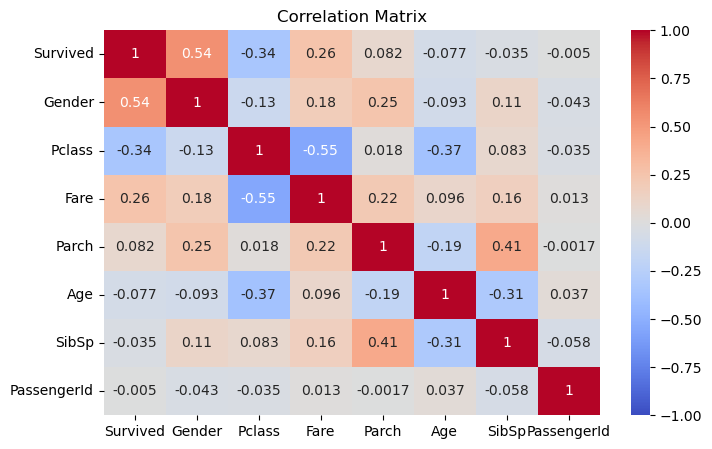

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

def corr_matrix(df, ft, count):
    corr = df.corr(numeric_only=True)
    count = min(count, len(corr.columns))
    top_corr = abs(corr[ft]).sort_values(ascending=False).iloc[:count]

    sz = min(15, count)
    plt.figure(figsize=(sz, sz-3))
    sns.heatmap(df[top_corr.index].corr(), vmax=1, vmin=-1, center=0, annot=True, cmap='coolwarm')
    plt.title('Correlation Matrix')
    plt.show()

corr_matrix(train, 'Survived', 10)

코더블: 보세요! 이렇게 상관계수를 정렬하니 훨씬 보기 좋네요. Gender와 Survived의 상관계수가 0.54로 가장 높게 나왔어요. 이는 우리가 전에 본 다른 어떤 변수보다도 생존과의 관계가 강하다는 의미예요. 그래서 이 변수를 추가했을 때 예측 정확도가 크게 향상된 거였군요! 객실 등급(Pclass)도 -0.34로 꽤 중요한 변수였지만, 성별보다는 영향력이 작았네요.

:::{note}
**모델 학습 코드의 재사용**

위의 모델 학습 코드는 앞으로 여러 섹션에서 반복적으로 사용됩니다. 다음 섹션부터는 이 코드가 "준비 코드"에 포함되어 있으므로, 매번 입력할 필요 없이 바로 실행 결과만 확인하면 됩니다.

준비 코드에 포함되는 내용:
1. 데이터 준비 (X, y, X_test 생성)
2. 학습/검증 데이터 분할
3. Random Forest 모델 학습
4. 성능 평가 및 예측 결과 저장

이는 마치 요리 책에서 기본 반죽을 미리 준비해두고 다양한 빵을 만드는 것과 같습니다.
:::

다안: 그래, 이 결과를 통해 우리는 타이타닉 침몰 상황에서 성별이 생존에 얼마나 결정적인 요소였는지 다시 한번 확인할 수 있었어. 지금까지의 결과를 표로 정리하면 다음과 같아:

| 버전 | 사용한 정보 수 | Val. Score | Public Score | 맞은 사람 수 | 사용한 정보 요약 |
| :--: | :-------: | :--------: | :----------: | :----------: | :---------------------: |
| 1.3  |     5     |  0.73184   |   0.63397    |    265명     | 수치형 정보만 사용 (Pclass, Age 등) |
| 2.1  |     6     |  0.82123   |   0.73444    |    307명     |    Gender 피쳐 추가     |

프롬: 단 하나의 변수를 추가했을 뿐인데 정확도가 10%p 이상 향상되었어요! 이는 성별이 생존 여부를 예측하는데 정말 중요한 요소였다는 걸 다시 한번 확인시켜주네요.

다안: 맞아. 그리고 이제 우리는 다음 단계로 나아갈 준비가 됐어. 다음 섹션에서는 승객들의 탑승 항구(Embarked) 정보를 추가하여 모델을 더욱 개선해볼 거야. 과연 이 정보는 예측 정확도를 얼마나 향상시킬 수 있을까?

프롬: 탑승 항구도 중요할 것 같아요! 각 항구마다 다른 특성의 승객들이 탑승했을 테니까요. 다음 시간이 기대돼요!

코더블: 저도 그 부분이 궁금했어요. 특히 각 항구별로 승객들의 사회경제적 배경이 달랐을 텐데, 그게 생존율에 영향을 미쳤을지 분석해보고 싶네요.

:::{admonition} 데이터 속 숨은 이야기 
:class: seealso

**"Women and children first"의 유래: 버켄헤드 규율**

타이타닉호에서 지켜진 "여성과 어린이 먼저"라는 원칙은 사실 그보다 60년 전인 1845년의 한 사건에서 비롯되었습니다. 영국 군함 HMS 버켄헤드(Birkenhead)가 남아프리카 해안에서 좌초했을 때의 일입니다.

침몰이 시작되자 함장은 제한된 구명보트에 여성과 어린이들을 먼저 태웠습니다. 그리고 남성 군인들은... 놀랍게도 침몰하는 배 위에 정렬해 서있었다고 합니다. 그들은 구명보트로 달려가는 혼란스러운 상황이 여성과 어린이의 탈출을 방해할 수 있다고 판단했기 때문입니다.

이 이야기는 빅토리아 시대 영국의 기사도 정신을 상징하는 사건이 되었고, "버켄헤드 규율(Birkenhead Drill)"이라는 이름으로 이후 해상 구조의 기본 원칙이 되었습니다.

타이타닉호의 경우 이 원칙이 잘 지켜져서 우리가 방금 확인한 것처럼 여성의 생존율(74.2%)이 남성(18.9%)보다 훨씬 높았습니다. 영화에서 보여준 여러 장면들, 특히 구명보트에 탑승하는 순서를 다루는 장면들은 이러한 역사적 맥락을 정확히 반영한 것이었죠.
:::

<br>